# Reading NetCDF Files
The following cells will guide you through opening a NetCDF file, interpretting what is in the file, visualizing the data and finally being able to export the data as an array for other libraries to read.

## Python libraries
Here is the installation for the libaries needed to process the data. If any libraries fail loading in the `load libraries` cell, revist what needs to be installed in `install libraries` cell. The installation only needs to run once.

In [4]:
# install libraries
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install netCDF4 xarray pandas matplotlib cartopy

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [56]:
# load libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
# open netcdf file and view summary
"""
note:
if you see a warning foy `pyproj`, it is okay to ignore. Just a warning about setting a path on the local machine.
It has not impact on the ability to use the library
"""

nc_path = "SIVelocity_SAR_20241015_115532_20241016_113140_v0.nc" # assuming file in in notebook directory
ds = xr.open_dataset(nc_path)
ds

C:\ProgramData\anaconda3\envs\noaa_ml\lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


<xarray.Dataset> Size: 3MB
Dimensions:     (time: 1, y: 315, x: 255)
Coordinates:
  * x           (x) float64 2kB 4.322e+05 4.332e+05 ... 6.852e+05 6.862e+05
  * y           (y) float64 3kB -1.705e+05 -1.695e+05 ... 1.425e+05 1.435e+05
  * time        (time) datetime64[ns] 8B 2024-10-15T11:55:31.999998976
Data variables:
    Speed_kmdy  (time, y, x) float64 643kB ...
    dx          (time, y, x) float64 643kB ...
    dy          (time, y, x) float64 643kB ...
    Bear_deg    (time, y, x) float64 643kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     SAR drift data converted from raw text form to...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-02-13T18:50:47Z
    time_coverage_start:       2024-10-15T11:55:32Z
    time_coverage_end:         2024-10-15T11:55:32Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

In [10]:
# high-level structure of the netcdf like the above output

print("Dimensions:", dict(ds.sizes), "\n")
print("Coordinates:", list(ds.coords), "\n")
print("Data variables:", list(ds.data_vars), "\n")
print("Attributes:", list(ds.attrs))

Dimensions: {'time': 1, 'y': 315, 'x': 255} 

Coordinates: ['x', 'y', 'time'] 

Data variables: ['Speed_kmdy', 'dx', 'dy', 'Bear_deg'] 

Attributes: ['Conventions', 'title', 'summary', 'acknowledgement', 'creator_name', 'creator_email', 'creator_institution', 'creator_type', 'creator_url', 'publisher_name', 'publisher_email', 'publisher_institution', 'publisher_type', 'publisher_url', 'contributor_name', 'contributor_role', 'processing_level', 'product_version', 'project', 'source', 'instrument', 'platform', 'platform_vocabulary', 'standard_name_vocabulary', 'keywords', 'keywords_vocabulary', 'license', 'history', 'references', 'metadata_link', 'sourceUrl', 'naming_authority', 'ncei_template_version', 'date_created', 'time_coverage_start', 'time_coverage_end', 'time_coverage_duration', 'time_coverage_resolution']


In [28]:
# getting familiar with the scope of the data

# lon/lat ranges
x = np.round(ds['x'].values, 3)
y = np.round(ds['y'].values, 3)
print(f'x range (m): {x.min()} to {x.max()}')
print(f'y range (m): {y.min()} to {y.max()}\n')

# approximate grid resolution (assumes regular spacing, median is cleaner)
dx_grid = np.median(np.diff(x))
dy_grid = np.median(np.diff(y))
print(f'Approximate resolution: {dx_grid} m (x) x {dy_grid} m (y)\n')

# all time(s) in dataset
print(f'Time coordinate: {ds["time"].values}')

x range (m): 432187.099 to 686187.099
y range (m): -170470.47 to 143529.53

Approximate resolution: 1000.0 m (x) x 1000.0 m (y)

Time coordinate: ['2024-10-15T11:55:31.999998976']


In [29]:
# variable metadata
metadata = []
for var in ds.data_vars:
    attrs = ds[var].attrs
    metadata.append(
        {
            'Variable': var,
            'Dims': ds[var].dims,
            'Dtype': ds[var].dtype,
            'Units': attrs['units'],
            'Standard Name': attrs['standard_name'],
            'Long Name': attrs['long_name']
        }
    )

pd.DataFrame(metadata) # display in nice data frame

,Variable,Dims,Dtype,Units,Standard Name,Long Name
0,Speed_kmdy,"(time, y, x)",float64,km/day,sea_ice_speed,Speed in km/day
1,dx,"(time, y, x)",float64,m/day,movement_in_x_direction,Zonal Velocity
2,dy,"(time, y, x)",float64,m/day,movement_in_y_direction,Meridional Velocity
3,Bear_deg,"(time, y, x)",float64,degrees,direction_true_north,Bearing


In [45]:
# better undertstanding the data (high-level exploratory data analysis)

stats = []
for t_idx, t in enumerate(ds['time'].values): # in case there are multiple time periods
    for var in ds.data_vars:
        da = ds[var].sel(time=t) # data array of values per time step
        arr = da.values
        valid = np.isfinite(arr) # ignore any NaN values
        invalid = np.isnan(arr)
        stats.append(
            {
                'Time Index': t_idx,
                'Time': t,
                'Variable': var,
                'Shape': arr.shape,
                'Valid Count': valid.sum(),
                'Invalid Count': invalid.sum(),
                'Valid Fraction': f'{str(np.round(valid.mean() * 100, 2))} %',
                'Min': np.round(np.nanmin(arr), 3),
                'Max': np.round(np.nanmax(arr), 3),
                'Mean': np.round(np.nanmean(arr), 3),
                'Median': np.round(np.nanmedian(arr), 3),
                'Standard Deviation': np.round(np.nanstd(arr), 3),
                'Sample Values': arr[valid][:5]
            }
        )

pd.DataFrame(stats)

,Time Index,Time,Variable,Shape,Valid Count,Invalid Count,Valid Fraction,Min,Max,Mean,Median,Standard Deviation,Sample Values
0,0,2024-10-15 11:55:31.999998976,Speed_kmdy,"(315, 255)",261,80064,0.32 %,0.379,20.480,13.211,13.163,3.803,"[11.03074, 11.37872, 3.58708, 11.08645, 11.43865]"
1,0,2024-10-15 11:55:31.999998976,dx,"(315, 255)",261,80064,0.32 %,-18479.848,17516.721,-11457.884,-11593.544,4101.903,"[-10463.597790997359, -10794.86185635184, -252..."
2,0,2024-10-15 11:55:31.999998976,dy,"(315, 255)",261,80064,0.32 %,-16088.418,9898.164,-4579.785,-4950.961,2390.026,"[-1656.6447637842502, -1712.055628253176, 2399..."
3,0,2024-10-15 11:55:31.999998976,Bear_deg,"(315, 255)",261,80064,0.32 %,29.386,359.758,328.343,334.703,42.697,"[336.02863, 336.2999, 29.38586, 334.64658, 335..."


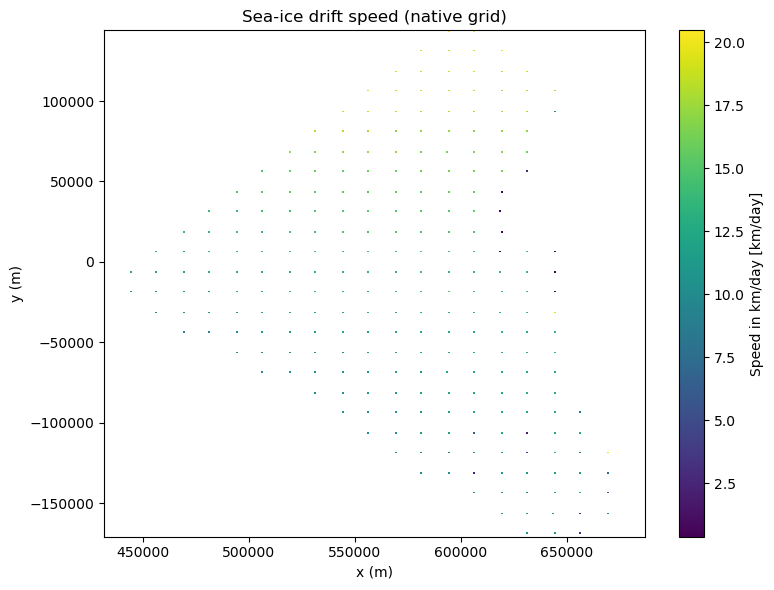

In [48]:
# let's see what the data looks like
# speed (km/day) on the native x/y grid

speed = ds["Speed_kmdy"].isel(time=0)

plt.figure(figsize=(8, 6))
im = plt.pcolormesh(ds["x"], ds["y"], speed, shading="auto")
plt.colorbar(im, label=f"{speed.attrs.get('long_name','Speed')} [{speed.attrs.get('units','')}]")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Sea-ice velocity (native grid)")
plt.tight_layout()
plt.show()

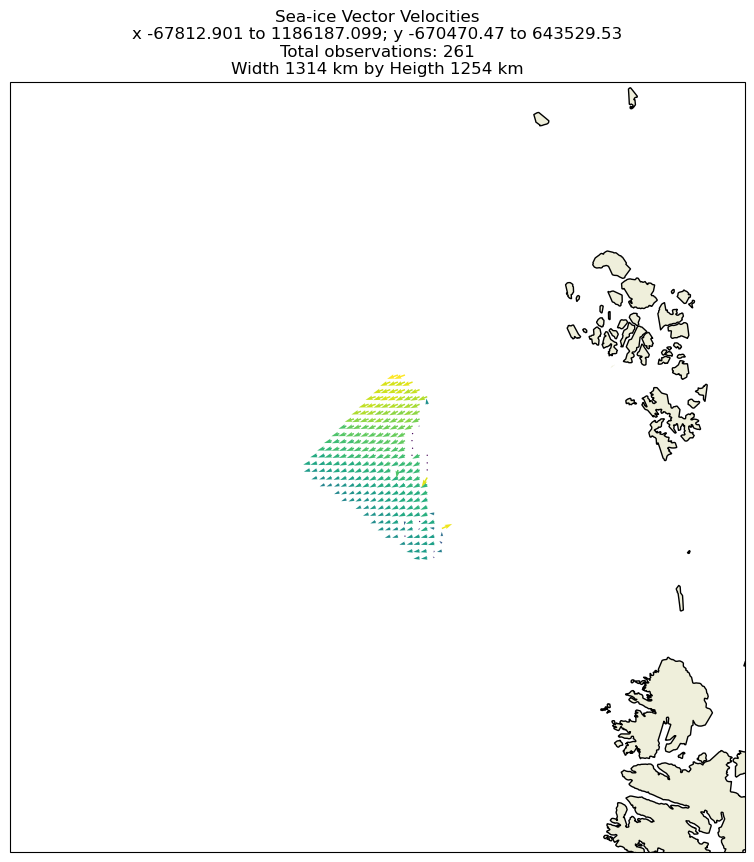

In [70]:
# plot vectors by using quivers

x_values = ds['x'].values
y_values = ds['y'].values
dx_values = ds["dx"].isel(time=0).values
dy_values = ds["dy"].isel(time=0).values
mag = np.hypot(dx_values, dy_values) / 1000 # values in km

# determine total valid observations
arr = ds['Speed_kmdy'].isel(time=0).values
valid = np.isfinite(arr) # ignore any NaN values

# set projection defined by data set
crs_3413 = ccrs.NorthPolarStereo(central_longitude=-45)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=crs_3413)

# Set extent in the projection's coordinate system (meters)
pad = 500_000 # 50km <-- change the pad to change scope of view
xmin = np.round(x_values.min() - pad, 3)
xmax = np.round(x_values.max() + pad, 3)
ymin = np.round(y_values.min() - pad, 3)
ymax = np.round(y_values.max() + pad, 3)

# set reasonable size of quivers based on dataset extent
map_width = xmax - xmin
map_height = ymax - ymin
map_span = np.round(max(map_height, map_width), 0)
if map_span > 2_000_000:
    quiver_scale = 0.1
else:
    quiver_scale = 1.0
ax.set_extent([xmin, xmax, ymin, ymax], crs=crs_3413)

# Coastlines / land
ax.add_feature(cfeature.LAND, zorder=0)
ax.coastlines(resolution="10m", linewidth=1.0, zorder=1)

ax.quiver(
    x_values, y_values, dx_values, dy_values, mag,
    transform=crs_3413,
    angles="xy", scale_units="xy",
    scale=quiver_scale,
    width=0.002, pivot="tail",
    color="green", zorder=2
)


ax.set_title(
    f"Sea-ice Vector Velocities\n"
    f"x {xmin} to {xmax}; y {ymin} to {ymax}\n"
    f"Total observations: {valid.sum()}\n"
    f"Width {np.int32(map_height / 1000)} km by Heigth {np.int32(map_width / 1000)} km"
)

plt.show()        

In [47]:
# Subsetting by time and x/y

# Select by time (works even if there is only one time)
da_speed = ds["Speed_kmdy"].sel(time=ds.time.values[0])
print(da_speed)

# subset of data set near center of grid extended by 50 km
xmid = float(ds.x.mean())
ymid = float(ds.y.mean())

subset = ds.sel(
    x=slice(xmid - 50_000, xmid + 50_000),
    y=slice(ymid - 50_000, ymid + 50_000),
)

subset

<xarray.DataArray 'Speed_kmdy' (y: 315, x: 255)> Size: 643kB
[80325 values with dtype=float64]
Coordinates:
  * x        (x) float64 2kB 4.322e+05 4.332e+05 ... 6.852e+05 6.862e+05
  * y        (y) float64 3kB -1.705e+05 -1.695e+05 ... 1.425e+05 1.435e+05
    time     datetime64[ns] 8B 2024-10-15T11:55:31.999998976
Attributes:
    long_name:      Speed in km/day
    standard_name:  sea_ice_speed
    ioos_category:  SAR daily sea-ice drift
    units:          km/day
    grid_mapping:   spatial_ref


<xarray.Dataset> Size: 322kB
Dimensions:     (time: 1, y: 100, x: 100)
Coordinates:
  * x           (x) float64 800B 5.092e+05 5.102e+05 ... 6.072e+05 6.082e+05
  * y           (y) float64 800B -6.247e+04 -6.147e+04 ... 3.553e+04 3.653e+04
  * time        (time) datetime64[ns] 8B 2024-10-15T11:55:31.999998976
Data variables:
    Speed_kmdy  (time, y, x) float64 80kB ...
    dx          (time, y, x) float64 80kB ...
    dy          (time, y, x) float64 80kB ...
    Bear_deg    (time, y, x) float64 80kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     SAR drift data converted from raw text form to...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-02-13T18:50:47Z
    time_coverage_start:       2024-10-15T11:55:32Z
    time_coverage_end:         2024-10-15T11:55:32Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

In [ ]:
# Export to NumPy arrays (for use in other Python tools)

# Pull arrays into memory (NumPy)
speed_np = ds["Speed_kmdy"].values        # shape (time, y, x)
dx_np    = ds["dx"].values               # shape (time, y, x)
dy_np    = ds["dy"].values               # shape (time, y, x)
bear_np  = ds["Bear_deg"].values         # shape (time, y, x)

x_np = ds["x"].values
y_np = ds["y"].values
t_np = ds["time"].values

print("speed_np:", speed_np.shape, speed_np.dtype)

# Save a compact bundle (recommended)
out_npz = "SIVelocity_export_arrays.npz"
np.savez_compressed(
    out_npz,
    Speed_kmdy=speed_np,
    dx=dx_np,
    dy=dy_np,
    Bear_deg=bear_np,
    x=x_np,
    y=y_np,
    time=t_np,
)

print("Wrote:", out_npz)

In [ ]:
# always close dataset
# accessing file from other locations or rerunning code can result in file locks or access conflicts
ds.close()